In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from lib.models import RegNetv3
from lib.data.dataloading import load_nursing_5_class
from lib.modules import optimization_loop_multi_class, evaluate_loop
import torch
from torch import nn
import matplotlib.pyplot as plt
import json
import numpy as np
from lib.utils import sample_regnet
from tqdm import tqdm
import pandas as pd
from pathlib import Path
import json

In [3]:
df = pd.DataFrame(columns=['n', 'd', 'w', 'nparams', 'best_f1', 'best_loss'])

for model_dir in Path('dev/n-search-shared').iterdir():
    config = json.load(open(model_dir / 'config.json'))
    info = json.load(open(model_dir / 'info.json'))
    nparams = sum([param.numel() for param in RegNetv3(CONFIG=config).parameters()])
    df.loc[len(df)] = {
        'n': int(config['N']),
        'd': config['DEPTHI'],
        'w': config['WIDTHI'],
        'nparams': nparams,
        'best_f1': sum(info['f1']) / len(info['f1']),
        'best_loss': info['loss']
    }
df['dw_str'] = df['d'].astype(str) + '-' + df['w'].astype(str)

In [5]:
df.sort_values('best_f1', ascending=False).head(10)

,n,d,w,nparams,best_f1,best_loss,dw_str
149,40,"[1, 2]","[40, 88]",45263,0.724196,0.690338,"[1, 2]-[40, 88]"
42,50,"[1, 2, 2]","[16, 88, 232]",277071,0.722189,0.695923,"[1, 2, 2]-[16, 88, 232]"
7,40,"[1, 2]","[24, 48]",15903,0.710164,0.784932,"[1, 2]-[24, 48]"
55,40,[2],[48],16647,0.708573,0.732008,[2]-[48]
13,50,[2],[48],16647,0.707029,0.724785,[2]-[48]
127,50,"[1, 2]","[24, 48]",15903,0.705574,0.720301,"[1, 2]-[24, 48]"
25,50,"[1, 2]","[40, 88]",45263,0.702827,0.712224,"[1, 2]-[40, 88]"
70,50,"[2, 2]","[56, 120]",92535,0.702742,0.743477,"[2, 2]-[56, 120]"
57,50,"[3, 11, 6]","[32, 80, 224]",1041847,0.700694,0.734986,"[3, 11, 6]-[32, 80, 224]"
77,50,[1],[56],12311,0.700073,0.730758,[1]-[56]


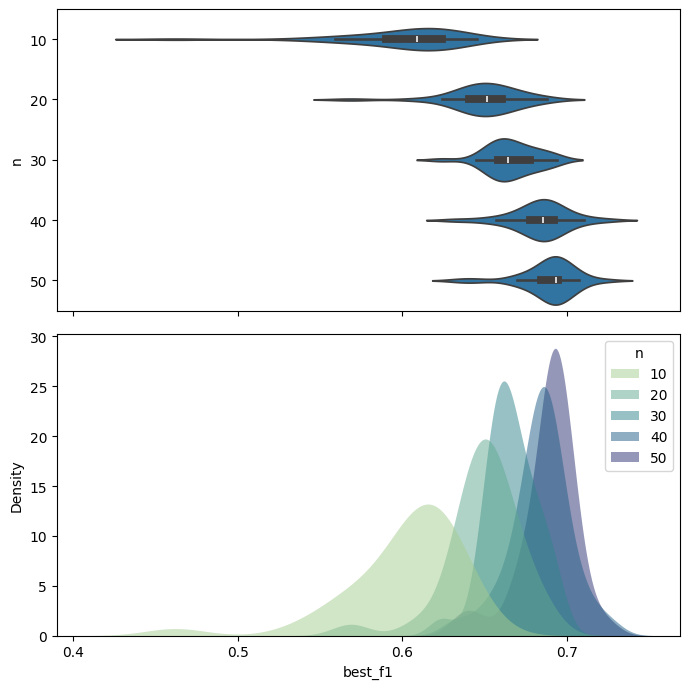

In [6]:
import seaborn as sns
fig, axes = plt.subplots(2, 1, figsize=(7,7), sharex=True)
sns.violinplot(data=df, x='best_f1', y='n', orient='h', ax=axes[0])
sns.kdeplot(data=df, x='best_f1', hue='n', fill=True, common_norm=False, alpha=0.5, palette='crest', linewidth=0, ax=axes[1])
start, end = axes[0].get_xlim()
plt.xticks(np.arange(start.round(1), end, 0.1))
plt.tight_layout()

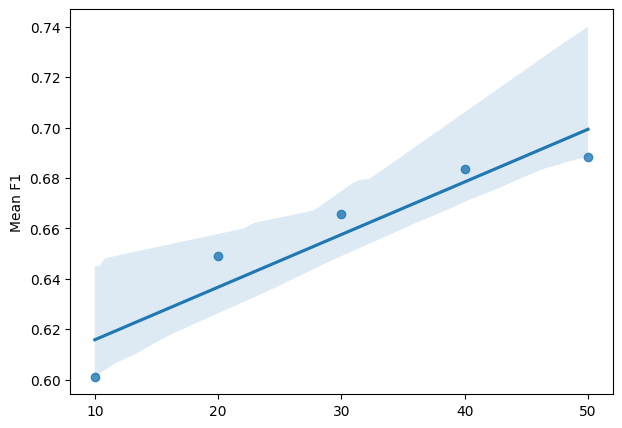

In [7]:
fig,ax = plt.subplots(1, figsize=(7,5), sharex=True)
dfbyn = df.groupby('n', as_index=False).mean(numeric_only=True)
sns.regplot(data=dfbyn, x='n', y='best_f1', ax=ax)
ax.set_ylabel('Mean F1')
ax.set_xlabel('')
ax.set_xticks(range(10, 60, 10));

# discretize nparams
# bins = df.nparams.quantile([0, 0.25, 0.5, 0.75, 1]).apply(lambda x: round(x, -4))
# df['nparams_binned'] = pd.cut(df.nparams, bins=bins, labels=[f'<{bins[0.25]}' , f'{bins[0.25]}-{bins[0.5]}', f'{bins[0.5]}-{bins[0.75]}', f'>{bins[0.75]}'])
# sns.boxplot(data=df, x='n', y='best_f1', hue='nparams_binned', ax=axes[1])
# axes[1].set_xticks(range(10, 60, 10))

# Data Augmentation

In [4]:
from lib.data.datasets import WindowedDatasetWithStrideAndModeOfLabel, DataAug
from lib.data.dataloading import load_nursing_aug, load_nursing_5_class
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, TensorDataset, ConcatDataset, Dataset
import os

In [8]:
import pandas as pd
from pathlib import Path
import json
from lib.models import RegNetv3

df = pd.DataFrame(columns=['idx', 'd', 'w', 'nparams', 'best_f1', 'best_loss', 'aug_mode'])

for model_dir_top in Path('dev/dataaug').iterdir():
    if model_dir_top.name.startswith('23'):
        continue
    for mode in ['identity-lstm', 'add_noise-lstm', 'interpolate-lstm', 'swap_channels-lstm', 'inject_step-lstm']:
        model_dir = model_dir_top / mode
        config = json.load(open(model_dir / 'config.json'))
        info = json.load(open(model_dir / 'info.json'))
        df.loc[len(df)] = {
            'idx': str(model_dir_top.name).split('-')[0],
            'd': config['DEPTHI'],
            'w': config['WIDTHI'],
            'nparams': sum([param.numel() for param in RegNetv3(CONFIG=config).parameters()]),
            'best_f1': sum(info['f1']) / len(info['f1']),
            'best_loss': info['loss'],
            'aug_mode': mode.split('-')[0]
        }

In [9]:
import seaborn as sns
def incr(x):
    id_f1 = df[(df.idx==x.idx) & (df.aug_mode=='identity')].best_f1.values[0]
    return x.best_f1 - id_f1
df['incr'] = df.apply(incr, axis=1)

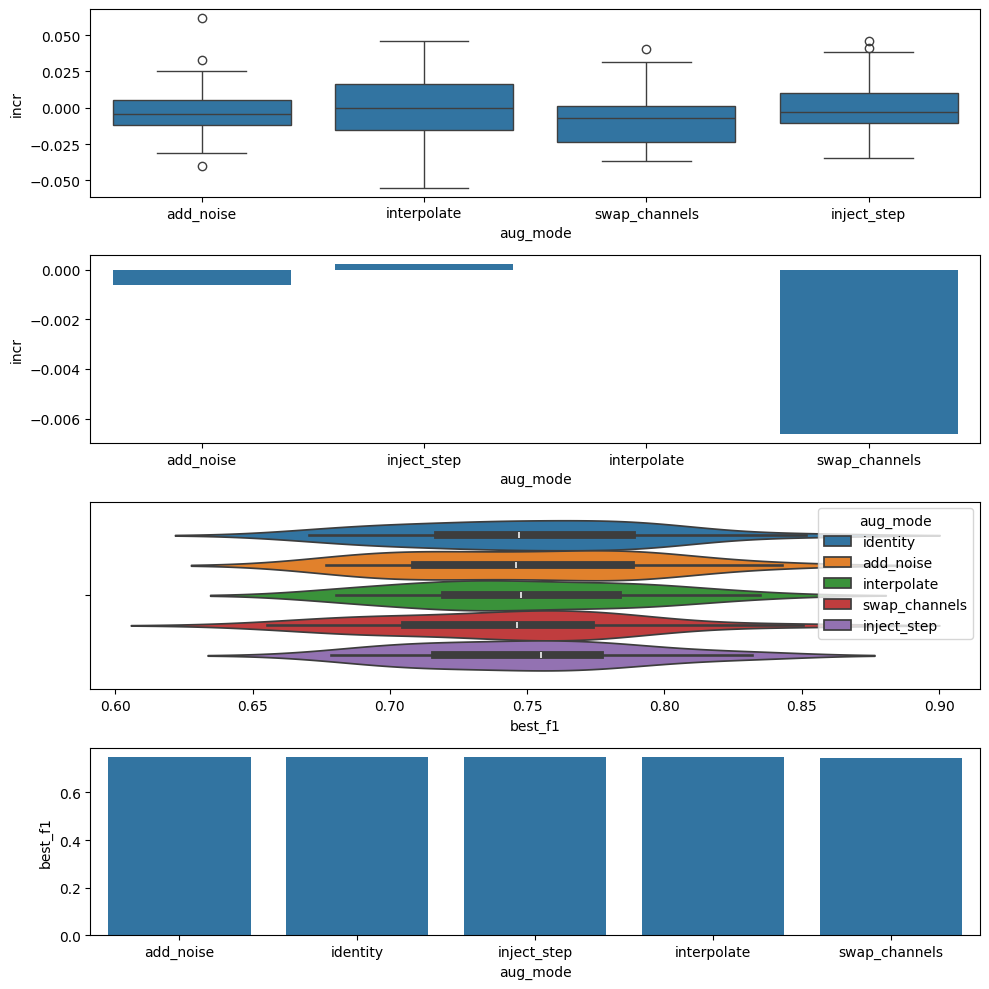

In [10]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(4, figsize=(10,10))
sns.boxplot(data=df[df.aug_mode != 'identity'], x='aug_mode', y='incr', ax=axes[0])
sns.barplot(data=df[df.aug_mode != 'identity'].groupby('aug_mode').mean(numeric_only=True), x='aug_mode', y='incr', ax=axes[1])
sns.violinplot(data=df, x='best_f1', hue='aug_mode', ax=axes[2])
sns.barplot(data=df.groupby('aug_mode').mean(numeric_only=True), x='aug_mode', y='best_f1', ax=axes[3])
plt.tight_layout()

# DataAug

https://arxiv.org/pdf/1702.05538.pdf

Interpolate between k-nearest neighbors of same class withing embedded space

In [4]:
from lib.models import DAE
from sklearn.model_selection import train_test_split

CONFIG = {
    'WINDOW_SIZE':1001,
    'WINDOW_STRIDE':1001 // 4,
    'NURSING_STRIDE': 1001,
    'BATCH_SIZE': 512,
    'LEARNING_RATE': 3e-4,
    'CLASS_LR': 3e-4,
    'ENC_LEARNING_RATE': 5e-5,
    'TEST_SIZE': 0.1,
    'NURSING_TEST_SIZE': 0.25,
    'DEVICE': 'cuda:1',
    'DEPTHI': [2,2],
    'WIDTHI': [48,128],
    'MASKPCT': 0.2,
    'PDROPOUT': 0.0
}
dir = Path('/home/musa/eating-detection/dev/10_dae/mask0.25-64-128-256-512')
CONFIG = json.load(open(dir / 'config.json'))
CONFIG['DEVICE'] = 'cuda:0'
model = DAE(CONFIG=CONFIG).to(CONFIG['DEVICE'])
model.load_state_dict(torch.load(dir / 'best_model.pt'))

# n=60
# nurses = np.random.choice(list(range(11,71)), n, replace=False)
# train_nurses, dev_nurses = train_test_split(nurses, test_size=CONFIG['NURSING_TEST_SIZE'])
# CONFIG['TRAIN_NURSES'] = train_nurses.tolist()
# CONFIG['VALIDATION'] = dev_nurses.tolist()
nursing_trainloader, nursing_testloader = load_nursing_5_class(
    split=(CONFIG['TRAIN_NURSES'], CONFIG['VALIDATION']),
    winsize=CONFIG['WINDOW_SIZE'],
    batch_size=CONFIG['BATCH_SIZE'],
    stride=CONFIG['NURSING_STRIDE'],
)

embedding = []
Xs = []
ys = []
shape = None
for i,(X,y) in enumerate(tqdm(nursing_trainloader)):
    with torch.no_grad():
        Xs.append(X)
        ys.append(y)
        X = X.to(CONFIG['DEVICE'])
        x = model.e(X)
        shape = x.shape
        embedding.append(x.detach().cpu())

X = torch.cat(Xs, dim=0)
y = torch.cat(ys, dim=0)
embedding = torch.cat(embedding, dim=0)
emb_mean = embedding.mean(dim=2)

100%|██████████| 57/57 [00:02<00:00, 25.24it/s]


In [5]:
# For each sample, find 10 nearest neighbors of same class

from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE

nearest_neighbors = []
distances = []
for classi in range(5):
    embi = emb_mean[y==classi]
    nbrs = NearestNeighbors(n_neighbors=10, algorithm='ball_tree').fit(embi)
    distancesi, indices = nbrs.kneighbors() # find for all embi - embi itself not included
    nearest_neighbors.append(indices)
    distances.append(distancesi)

Distance:  3.31020299875586


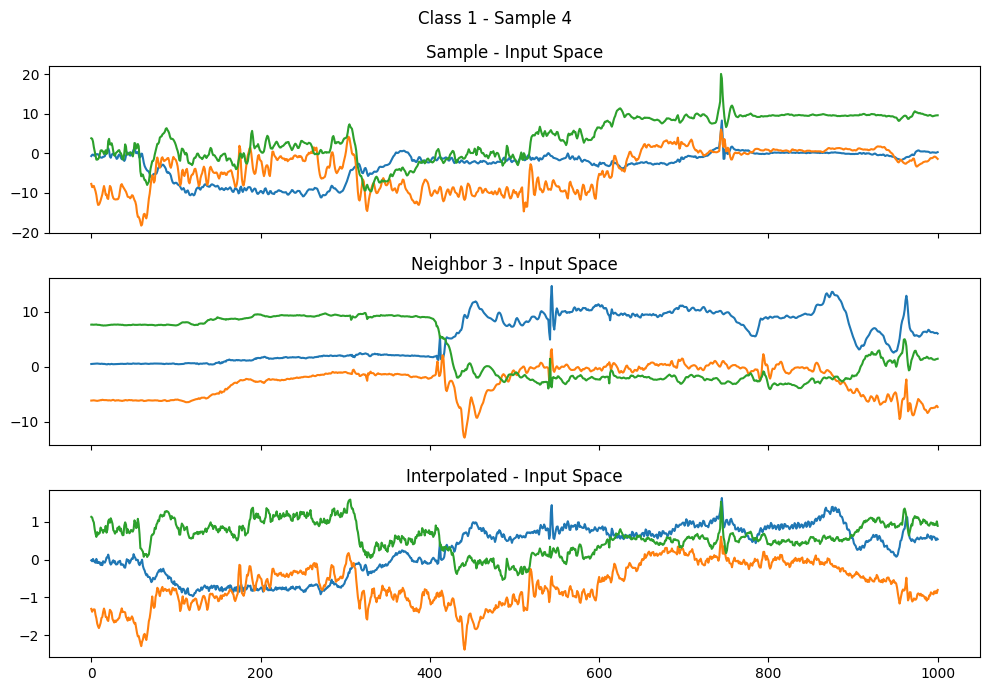

In [6]:
classi = 1
idx = 4
neighbor_idx = 3
Xi = X[y==classi][idx]
Xi_neighbors = X[nearest_neighbors[classi][idx]]

print("Distance: ", distances[classi][idx][neighbor_idx])

embi = embedding[y==classi][idx]
embi_neighbors = embedding[nearest_neighbors[classi][idx]]
cprime = (embi_neighbors[neighbor_idx] - embi) * 0.5 + embi
xprime = model.decoder(cprime.unsqueeze(0).to(CONFIG['DEVICE'])).squeeze().cpu().detach().numpy()

fig, ax = plt.subplots(3, sharex=True, figsize=(10,7))
fig.suptitle(f'Class {classi} - Sample {idx}')
ax[0].plot(Xi[0])
ax[0].plot(Xi[1])
ax[0].plot(Xi[2])
ax[0].set_title('Sample - Input Space')

ax[1].plot(Xi_neighbors[neighbor_idx,0])
ax[1].plot(Xi_neighbors[neighbor_idx,1])
ax[1].plot(Xi_neighbors[neighbor_idx,2])
ax[1].set_title(f'Neighbor {neighbor_idx} - Input Space')

ax[2].plot(xprime[0])
ax[2].plot(xprime[1])
ax[2].plot(xprime[2])
ax[2].set_title('Interpolated - Input Space')

plt.tight_layout()

In [9]:
from lib.dataaug import load_nursing_interpolated

trainloader, devloader = load_nursing_interpolated(
    split=(CONFIG['TRAIN_NURSES'], CONFIG['VALIDATION']),
    winsize=CONFIG['WINDOW_SIZE'],
    batch_size=CONFIG['BATCH_SIZE'],
    stride=CONFIG['NURSING_STRIDE'],
    model_path='/home/musa/eating-detection/dev/10_dae/mask0.25-64-128-256-512/',
    k=10
)

In [5]:
for model_dir_top in Path('dev/dataauginterp').iterdir():
    if model_dir_top.name.startswith('33'):
        continue
    model_dir = model_dir_top / 'interped-lstm'
    config = json.load(open(model_dir / 'config.json'))
    info = json.load(open(model_dir / 'info.json'))
    config['INTERPOLATED'] = True
    json.dump(config, open(model_dir / 'config.json', 'w'))

In [6]:
df = pd.DataFrame(columns=['idx', 'd', 'w', 'nparams', 'best_f1', 'best_loss', 'interpolated'])
for model_top_dir in Path('dev/dataauginterp').iterdir():
    if model_top_dir.name.startswith('33'):
        continue
    for int_mode in ['interped', 'nointerped']:
        model_dir = model_top_dir / (int_mode + '-lstm')
        config = json.load(open(model_dir / 'config.json'))
        info = json.load(open(model_dir / 'info.json'))
        df.loc[len(df)] = {
            'idx': str(model_top_dir.name).split('-')[0],
            'd': config['DEPTHI'],
            'w': config['WIDTHI'],
            'nparams': sum([param.numel() for param in RegNetv3(CONFIG=config).parameters()]),
            'best_f1': sum(info['f1']) / len(info['f1']),
            'best_loss': info['loss'],
            'interpolated': config['INTERPOLATED']
        }

In [7]:
def incr(x):
    id_f1 = df[(df.idx==x.idx) & (~df.interpolated)].best_f1.values[0]
    return x.best_f1 - id_f1
df['incr'] = df.apply(incr, axis=1)

In [11]:
df.groupby('interpolated').mean(numeric_only=True)

,nparams,best_f1,best_loss,incr
interpolated,,,,
False,869939.38191,0.715576,0.772853,0.000000
True,869939.38191,0.717029,0.760779,0.001453


(-10000.0, 500000.0)

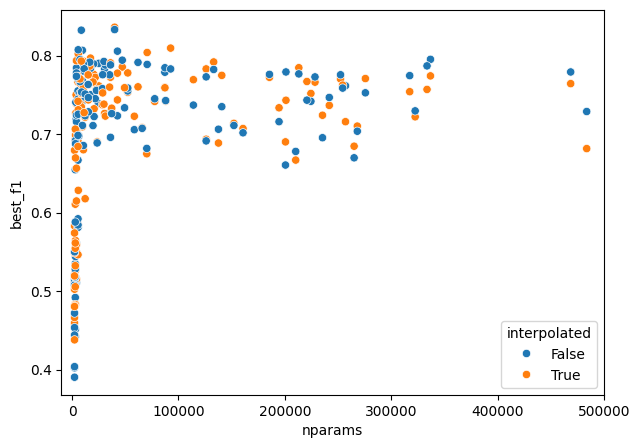

In [9]:
import seaborn as sns
fig, ax = plt.subplots(1, figsize=(7,5))
sns.scatterplot(df, x='nparams', y='best_f1', hue='interpolated', ax=ax)
ax.set_xlim(-1e4, 500_000)